# Customer Churn Analysis and Prediction

### End-to-End Data Analysis and Machine Learning Project

**Objective:**  
Analyze customer behavior and identify patterns associated with customer churn, then build and evaluate machine learning models to predict customers who are likely to churn.

## 1. Project Overview

Customer churn is an important business problem for subscription-based companies because retaining existing customers can be more efficient than continuously acquiring new ones.

In this project, customer usage, engagement, subscription, complaint, and customer value data are analyzed to understand patterns associated with churn.

The project follows an end-to-end workflow:

- Data understanding and cleaning
- Exploratory Data Analysis (EDA)
- Statistical analysis
- Feature engineering and preprocessing
- Machine learning model development
- Model evaluation and comparison
- Feature importance analysis
- Business insights and interpretation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("Raw Data/Customer Churn.csv")

In [3]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [4]:
df.shape

(3150, 14)

In [5]:
df.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)
memory usa

In [7]:
df.isnull().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(300)

In [9]:
df[df.duplicated()].head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
518,0,0,37,0,0,0,0,0,2,1,2,25,0.0,1
628,0,0,35,0,0,0,0,0,2,1,2,25,0.0,1
718,0,0,37,0,0,0,0,0,2,1,2,25,0.0,1
728,0,0,36,0,0,0,0,0,3,1,2,30,0.0,1
901,0,0,38,0,0,0,0,0,2,1,2,25,0.0,0


In [10]:
df = df.drop_duplicates().copy()
print(df.shape)

(2850, 14)


In [11]:
df.dtypes


Call  Failure                int64
Complains                    int64
Subscription  Length         int64
Charge  Amount               int64
Seconds of Use               int64
Frequency of use             int64
Frequency of SMS             int64
Distinct Called Numbers      int64
Age Group                    int64
Tariff Plan                  int64
Status                       int64
Age                          int64
Customer Value             float64
Churn                        int64
dtype: object

In [12]:
df.nunique()

Call  Failure                37
Complains                     2
Subscription  Length         45
Charge  Amount               11
Seconds of Use             1756
Frequency of use            242
Frequency of SMS            405
Distinct Called Numbers      92
Age Group                     5
Tariff Plan                   2
Status                        2
Age                           5
Customer Value             2654
Churn                         2
dtype: int64

In [13]:
df["Churn"].value_counts()

Churn
0    2404
1     446
Name: count, dtype: int64

In [14]:
df["Churn"].value_counts(normalize=True)*100

Churn
0    84.350877
1    15.649123
Name: proportion, dtype: float64

In [15]:
df.groupby("Churn")["Customer Value"].mean()

Churn
0    538.590759
1    132.175695
Name: Customer Value, dtype: float64

In [16]:
df.groupby("Complains")["Churn"].mean()

Complains
0    0.097710
1    0.826087
Name: Churn, dtype: float64

In [17]:
df.groupby("Tariff Plan")["Churn"].mean()

Tariff Plan
1    0.167875
2    0.026201
Name: Churn, dtype: float64

In [18]:
df.groupby("Status")["Churn"].mean()

Status
1    0.055863
2    0.475146
Name: Churn, dtype: float64

In [19]:
df.groupby("Age Group")["Churn"].mean()

Age Group
1    0.000000
2    0.170467
3    0.164352
4    0.201635
5    0.012987
Name: Churn, dtype: float64

In [20]:
df.groupby("Churn")["Subscription  Length"].mean()

Churn
0    32.595674
1    31.683857
Name: Subscription  Length, dtype: float64

In [21]:
df.groupby("Churn")["Seconds of Use"].mean()

Churn
0    5069.588186
1    1648.661435
Name: Seconds of Use, dtype: float64

In [22]:
df.groupby("Churn")["Frequency of use"].mean()

Churn
0    77.866473
1    30.697309
Name: Frequency of use, dtype: float64

In [23]:
df.groupby("Churn")["Frequency of SMS"].mean()

Churn
0    84.353577
1    16.849776
Name: Frequency of SMS, dtype: float64

In [24]:
df.groupby("Churn")["Distinct Called Numbers"].mean()

Churn
0    25.872296
1    13.080717
Name: Distinct Called Numbers, dtype: float64

In [25]:
df.groupby("Churn")["Call  Failure"].mean()

Churn
0    7.792013
1    7.858744
Name: Call  Failure, dtype: float64

In [26]:
df.groupby("Churn")["Charge  Amount"].mean()

Churn
0    1.109401
1    0.248879
Name: Charge  Amount, dtype: float64

In [27]:
df.groupby("Churn")["Age"].mean()


Churn
0    31.121048
1    30.840807
Name: Age, dtype: float64

<Axes: xlabel='Churn', ylabel='Customer Value'>

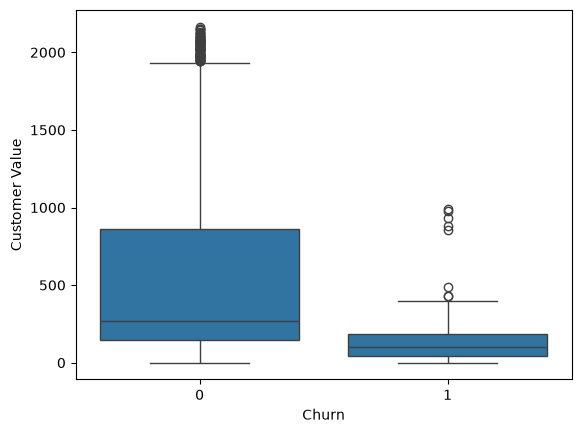

In [28]:
sns.boxplot(data=df, x="Churn", y="Customer Value")

<Axes: xlabel='Churn', ylabel='count'>

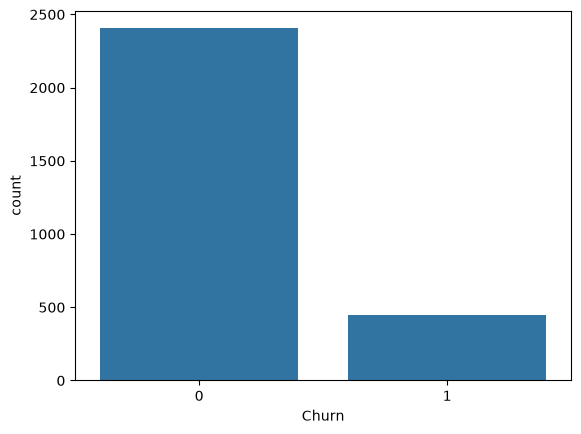

In [29]:
sns.countplot(data=df, x="Churn")

<Axes: xlabel='Complains', ylabel='count'>

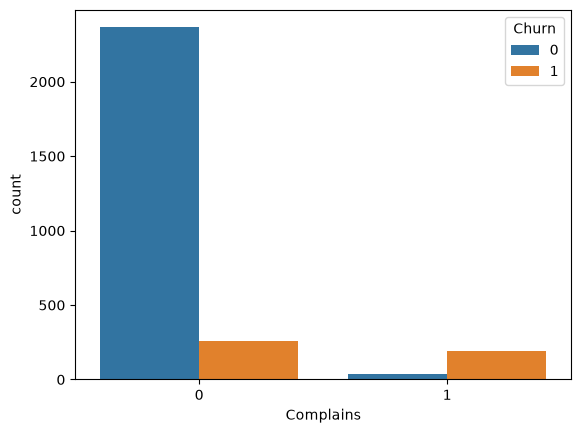

In [30]:
sns.countplot(data=df, x="Complains", hue="Churn")

<Axes: xlabel='Tariff Plan', ylabel='count'>

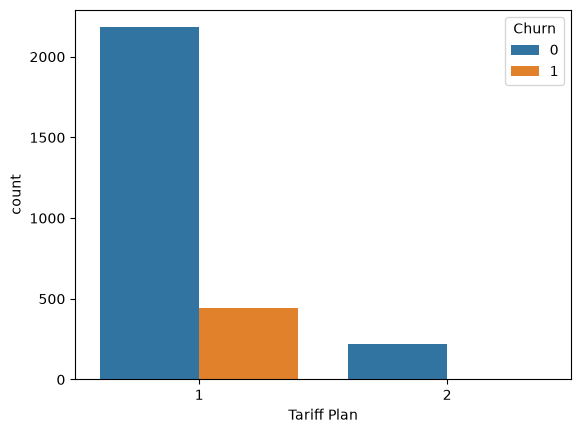

In [31]:
sns.countplot(data=df, x="Tariff Plan", hue="Churn")

<Axes: xlabel='Status', ylabel='count'>

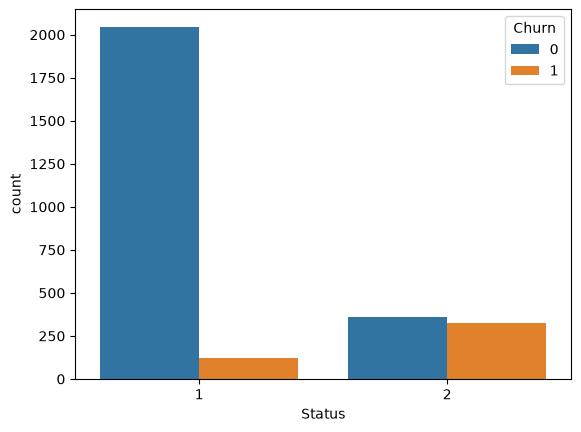

In [32]:
sns.countplot(data=df, x="Status", hue="Churn")

<Axes: xlabel='Age Group', ylabel='count'>

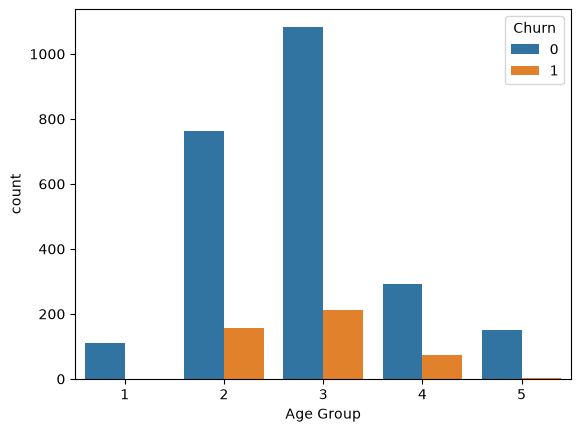

In [33]:
sns.countplot(data=df, x="Age Group", hue="Churn")

<Axes: xlabel='Churn', ylabel='Seconds of Use'>

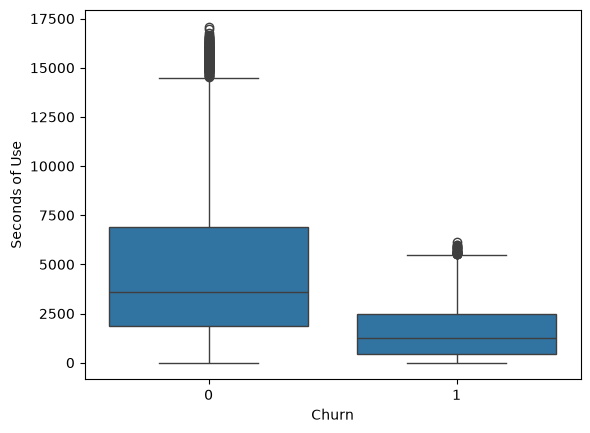

In [34]:
sns.boxplot(data=df, x="Churn", y="Seconds of Use")

<Axes: xlabel='Churn', ylabel='Frequency of use'>

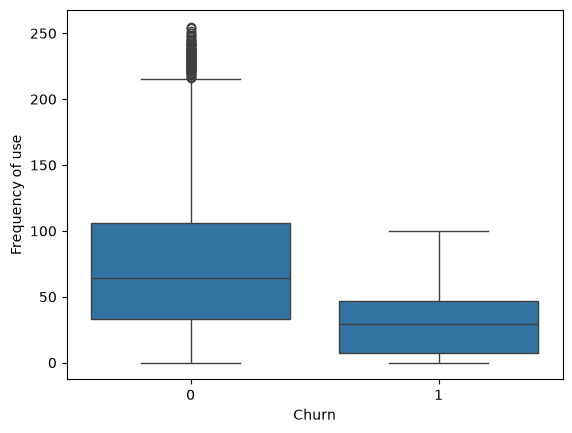

In [35]:
sns.boxplot(data=df, x="Churn", y="Frequency of use")

<Axes: xlabel='Churn', ylabel='Frequency of SMS'>

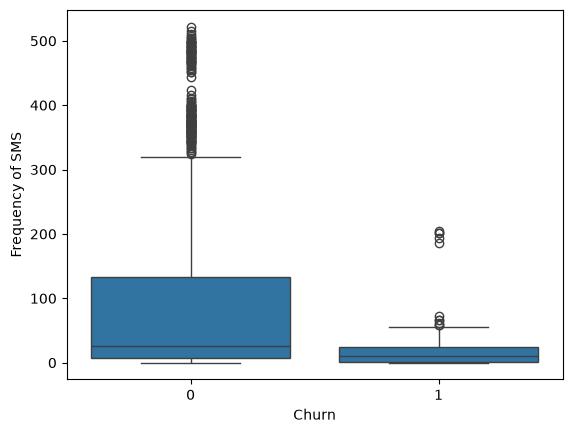

In [36]:
sns.boxplot(data=df, x="Churn", y="Frequency of SMS")

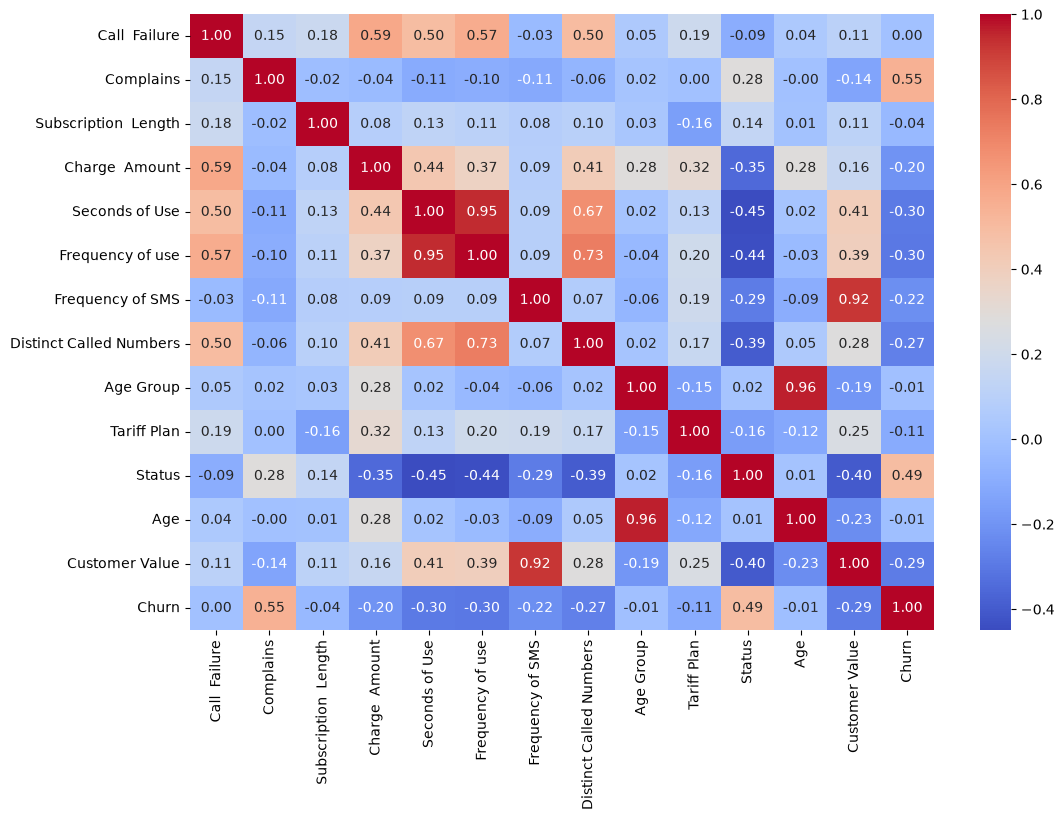

In [37]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

### Statistical Analysis  ###

Descriptive Statistics


In [38]:
numeric_cols = [
    "Customer Value",
    "Seconds of Use",
    "Frequency of use",
    "Frequency of SMS",
    "Subscription  Length",
    "Call  Failure",
    "Distinct Called Numbers"
]

descriptive_stats = df[numeric_cols].describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
Customer Value,2850.0,474.990367,514.442198,0.0,117.5275,232.52,790.08,2165.28
Seconds of Use,2850.0,4534.243158,4199.712303,0.0,1458.7500,3041.00,6500.00,17090.00
Frequency of use,2850.0,70.484912,57.401512,0.0,28.0000,54.50,96.00,255.00
Frequency of SMS,2850.0,73.789825,112.062397,0.0,7.0000,22.00,88.00,522.00
Subscription Length,2850.0,32.452982,8.723075,3.0,29.0000,35.00,38.00,47.00
Call Failure,2850.0,7.802456,7.326172,0.0,1.0000,6.00,12.00,36.00
Distinct Called Numbers,2850.0,23.870526,17.193929,0.0,11.0000,21.00,34.00,97.00


In [39]:
mode_stats = df[numeric_cols].mode().iloc[0]
variance_stats = df[numeric_cols].var()
iqr_stats = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)

extra_stats = pd.DataFrame({
    "Mode": mode_stats,
    "Variance": variance_stats,
    "IQR": iqr_stats
})

extra_stats

,Mode,Variance,IQR
Customer Value,0.0,2.646508e+05,672.5525
Seconds of Use,0.0,1.763758e+07,5041.2500
Frequency of use,0.0,3.294934e+03,68.0000
Frequency of SMS,0.0,1.255798e+04,81.0000
Subscription Length,36.0,7.609203e+01,9.0000
Call Failure,0.0,5.367279e+01,11.0000
Distinct Called Numbers,0.0,2.956312e+02,23.0000


Churned vs Non-Churned comparison

In [40]:
comparison = df.groupby("Churn")[numeric_cols].agg(["mean", "median"])

comparison

Customer Value          Seconds of Use         Frequency of use         \
                mean   median           mean  median             mean median   
Churn                                                                          
0         538.590759  271.540    5069.588186  3596.5        77.866473   64.0   
1         132.175695  102.565    1648.661435  1256.5        30.697309   29.0   

      Frequency of SMS        Subscription  Length        Call  Failure  \
                  mean median                 mean median          mean   
Churn                                                                     
0            84.353577   26.0            32.595674   35.0      7.792013   
1            16.849776   11.0            31.683857   35.0      7.858744   

             Distinct Called Numbers         
      median                    mean median  
Churn                                        
0        6.0               25.872296   24.0  
1        6.0               13.080717   11.0

In [41]:
from scipy.stats import mannwhitneyu

In [42]:
churned = df[df["Churn"] == 1]["Customer Value"]
not_churned = df[df["Churn"] == 0]["Customer Value"]

stat, p_value = mannwhitneyu(churned, not_churned)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 234722.5
p-value: 1.585944115613227e-79


In [43]:
churned_usage = df[df["Churn"] == 1]["Seconds of Use"]
not_churned_usage = df[df["Churn"] == 0]["Seconds of Use"]

stat, p_value = mannwhitneyu(churned_usage, not_churned_usage)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 229084.0
p-value: 1.8437818364023188e-82


In [44]:
churned_freq = df[df["Churn"] == 1]["Frequency of use"]
not_churned_freq = df[df["Churn"] == 0]["Frequency of use"]

stat, p_value = mannwhitneyu(churned_freq, not_churned_freq)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 249981.5
p-value: 7.228963050346978e-72


In [45]:
churned_sms = df[df["Churn"] == 1]["Frequency of SMS"]
not_churned_sms = df[df["Churn"] == 0]["Frequency of SMS"]

stat, p_value = mannwhitneyu(churned_sms, not_churned_sms)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 353687.0
p-value: 1.9667108567029605e-30


In [46]:
churned_sub = df[df["Churn"] == 1]["Subscription  Length"]
not_churned_sub = df[df["Churn"] == 0]["Subscription  Length"]

stat, p_value = mannwhitneyu(churned_sub, not_churned_sub)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 507973.0
p-value: 0.07770285281408061


In [47]:
churned_failure = df[df["Churn"] == 1]["Call  Failure"]
not_churned_failure = df[df["Churn"] == 0]["Call  Failure"]

stat, p_value = mannwhitneyu(churned_failure, not_churned_failure)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 523652.0
p-value: 0.43313477834582126


In [48]:
churned_numbers = df[df["Churn"] == 1]["Distinct Called Numbers"]
not_churned_numbers = df[df["Churn"] == 0]["Distinct Called Numbers"]

stat, p_value = mannwhitneyu(churned_numbers, not_churned_numbers)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 288388.0
p-value: 2.4134103670814116e-54


In [49]:
from scipy.stats import chi2_contingency

In [50]:
contingency_table = pd.crosstab(df["Complains"], df["Churn"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 844.2918529832452
p-value: 1.2662937233962688e-185


In [51]:
contingency_table = pd.crosstab(df["Tariff Plan"], df["Churn"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 30.95844174655926
p-value: 2.6361297947004973e-08


In [52]:
contingency_table = pd.crosstab(df["Status"], df["Churn"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 689.1431939387269
p-value: 6.8645838862667365e-152


In [53]:
contingency_table = pd.crosstab(df["Age Group"], df["Churn"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 52.43956100292364
p-value: 1.1162941023358962e-10


In [54]:
contingency_table = pd.crosstab(df["Complains"], df["Churn"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

n = contingency_table.sum().sum()
phi2 = chi2 / n

cramers_v = np.sqrt(phi2 / min(contingency_table.shape[0] - 1,
                               contingency_table.shape[1] - 1))

print("Cramer's V:", cramers_v)

Cramer's V: 0.5442818713063274


In [55]:
contingency_table = pd.crosstab(df["Tariff Plan"], df["Churn"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

n = contingency_table.sum().sum()
phi2 = chi2 / n

cramers_v = np.sqrt(phi2 / min(contingency_table.shape[0] - 1,
                               contingency_table.shape[1] - 1))

print("Cramer's V:", cramers_v)

Cramer's V: 0.1042238511049347


In [56]:
contingency_table = pd.crosstab(df["Status"], df["Churn"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

n = contingency_table.sum().sum()
phi2 = chi2 / n

cramers_v = np.sqrt(phi2 / min(contingency_table.shape[0] - 1,
                               contingency_table.shape[1] - 1))

print("Cramer's V:", cramers_v)

Cramer's V: 0.49173634139870614


In [57]:
contingency_table = pd.crosstab(df["Age Group"], df["Churn"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

n = contingency_table.sum().sum()
phi2 = chi2 / n

cramers_v = np.sqrt(phi2 / min(contingency_table.shape[0] - 1,
                               contingency_table.shape[1] - 1))

print("Cramer's V:", cramers_v)

Cramer's V: 0.13564603188423213


In [58]:
n1 = len(churned)
n2 = len(not_churned)

rank_biserial = 1 - (2 * stat) / (n1 * n2)

print("Rank-biserial correlation:", rank_biserial)

Rank-biserial correlation: 0.4620550204069451


In [59]:
churned = df[df["Churn"] == 1]["Seconds of Use"]
not_churned = df[df["Churn"] == 0]["Seconds of Use"]

stat, p_value = mannwhitneyu(churned, not_churned)

n1 = len(churned)
n2 = len(not_churned)

rank_biserial = 1 - (2 * stat) / (n1 * n2)

print("U statistic:", stat)
print("p-value:", p_value)
print("Rank-biserial correlation:", rank_biserial)

U statistic: 229084.0
p-value: 1.8437818364023188e-82
Rank-biserial correlation: 0.5726778239555896


In [60]:
churned = df[df["Churn"] == 1]["Frequency of use"]
not_churned = df[df["Churn"] == 0]["Frequency of use"]

stat, p_value = mannwhitneyu(churned, not_churned)

n1 = len(churned)
n2 = len(not_churned)

rank_biserial = 1 - (2 * stat) / (n1 * n2)

print("U statistic:", stat)
print("p-value:", p_value)
print("Rank-biserial correlation:", rank_biserial)

U statistic: 249981.5
p-value: 7.228963050346978e-72
Rank-biserial correlation: 0.5336966416212143


In [61]:
churned = df[df["Churn"] == 1]["Frequency of SMS"]
not_churned = df[df["Churn"] == 0]["Frequency of SMS"]

stat, p_value = mannwhitneyu(churned, not_churned)

n1 = len(churned)
n2 = len(not_churned)

rank_biserial = 1 - (2 * stat) / (n1 * n2)

print("U statistic:", stat)
print("p-value:", p_value)
print("Rank-biserial correlation:", rank_biserial)

U statistic: 353687.0
p-value: 1.9667108567029605e-30
Rank-biserial correlation: 0.3402494347985048


In [62]:
churned = df[df["Churn"] == 1]["Subscription  Length"]
not_churned = df[df["Churn"] == 0]["Subscription  Length"]

stat, p_value = mannwhitneyu(churned, not_churned)

n1 = len(churned)
n2 = len(not_churned)

rank_biserial = 1 - (2 * stat) / (n1 * n2)

print("U statistic:", stat)
print("p-value:", p_value)
print("Rank-biserial correlation:", rank_biserial)

U statistic: 507973.0
p-value: 0.07770285281408061
Rank-biserial correlation: 0.05245181797154219


In [63]:
churned = df[df["Churn"] == 1]["Call  Failure"]
not_churned = df[df["Churn"] == 0]["Call  Failure"]

stat, p_value = mannwhitneyu(churned, not_churned)

n1 = len(churned)
n2 = len(not_churned)

rank_biserial = 1 - (2 * stat) / (n1 * n2)

print("U statistic:", stat)
print("p-value:", p_value)
print("Rank-biserial correlation:", rank_biserial)

U statistic: 523652.0
p-value: 0.43313477834582126
Rank-biserial correlation: 0.023204972280877145


In [64]:
churned = df[df["Churn"] == 1]["Distinct Called Numbers"]
not_churned = df[df["Churn"] == 0]["Distinct Called Numbers"]

stat, p_value = mannwhitneyu(churned, not_churned)

n1 = len(churned)
n2 = len(not_churned)

rank_biserial = 1 - (2 * stat) / (n1 * n2)

print("U statistic:", stat)
print("p-value:", p_value)
print("Rank-biserial correlation:", rank_biserial)

U statistic: 288388.0
p-value: 2.4134103670814116e-54
Rank-biserial correlation: 0.4620550204069451


### Machine Learning ###

In [65]:
df["Age"].value_counts().sort_index()

Age
15     112
25     921
30    1296
45     367
55     154
Name: count, dtype: int64

In [66]:
df["Age Group"].value_counts().sort_index()

Age Group
1     112
2     921
3    1296
4     367
5     154
Name: count, dtype: int64

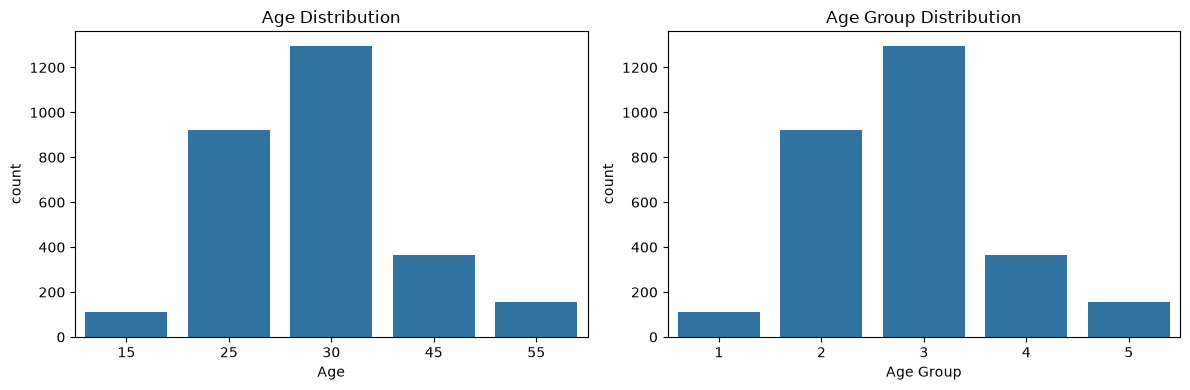

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="Age", ax=axes[0])
axes[0].set_title("Age Distribution")

sns.countplot(data=df, x="Age Group", ax=axes[1])
axes[1].set_title("Age Group Distribution")

plt.tight_layout()
plt.show()

In [68]:
df.groupby("Age Group")["Age"].agg(["min", "max", "count"])

,min,max,count
Age Group,,,
1,15,15,112
2,25,25,921
3,30,30,1296
4,45,45,367
5,55,55,154


In [69]:
X = df.drop(columns=["Churn", "Age Group"])
y = df["Churn"]

In [70]:
X.shape,y.shape

((2850, 12), (2850,))

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [72]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2280, 12), (570, 12), (2280,), (570,))

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [74]:
numeric_features = [
    "Call  Failure",
    "Subscription  Length",
    "Charge  Amount",
    "Seconds of Use",
    "Frequency of use",
    "Frequency of SMS",
    "Distinct Called Numbers",
    "Age",
    "Customer Value"
]

categorical_features = [
    "Complains",
    "Tariff Plan",
    "Status"
]

In [75]:
from sklearn.preprocessing import OneHotEncoder

In [76]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [77]:
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [78]:
X_train_processed.shape, X_test_processed.shape

((2280, 15), (570, 15))

In [79]:
from sklearn.linear_model import LogisticRegression

In [80]:
model = LogisticRegression(random_state=42)

In [81]:
model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [82]:
y_pred = model.predict(X_test_processed)

In [83]:
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [84]:
from sklearn.metrics import accuracy_score

In [85]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9035087719298246


In [86]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       481
           1       0.83      0.48      0.61        89

    accuracy                           0.90       570
   macro avg       0.87      0.73      0.78       570
weighted avg       0.90      0.90      0.89       570



In [87]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[472   9]
 [ 46  43]]


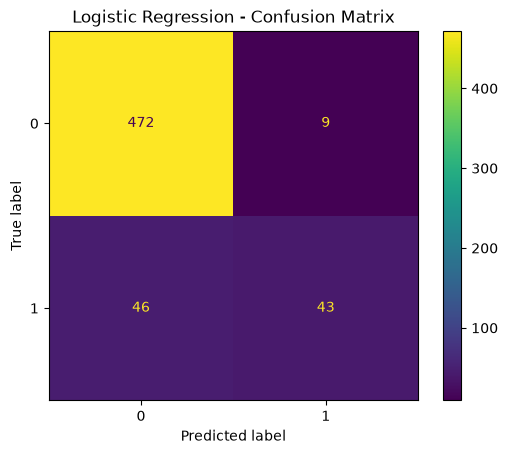

In [88]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [89]:
from sklearn.tree import DecisionTreeClassifier

In [90]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

In [91]:
tree_model.fit(X_train_processed, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [92]:
tree_pred = tree_model.predict(X_test_processed)

In [93]:
tree_pred[:20]

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [94]:
tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.9122807017543859


In [95]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       481
           1       0.80      0.58      0.68        89

    accuracy                           0.91       570
   macro avg       0.86      0.78      0.81       570
weighted avg       0.91      0.91      0.91       570



In [96]:
from sklearn.ensemble import RandomForestClassifier

In [97]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=8
)

In [98]:
rf_model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [99]:
rf_pred = rf_model.predict(X_test_processed)

In [100]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9368421052631579


In [101]:
print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       0.94      0.99      0.96       481
           1       0.92      0.65      0.76        89

    accuracy                           0.94       570
   macro avg       0.93      0.82      0.86       570
weighted avg       0.94      0.94      0.93       570



In [102]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[476   5]
 [ 31  58]]


In [103]:
from sklearn.neighbors import KNeighborsClassifier

In [104]:
from sklearn.model_selection import train_test_split, cross_val_score

In [105]:
k_values = [3, 5, 7, 9, 11]

knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_processed,
        y_train,
        cv=5,
        scoring="f1"
    )

    knn_results.append({
        "K": k,
        "Mean F1": scores.mean()
    })

knn_tuning = pd.DataFrame(knn_results)

knn_tuning

,K,Mean F1
0,3,0.833995
1,5,0.813027
2,7,0.807746
3,9,0.804365
4,11,0.805623


In [106]:
knn_tuned = KNeighborsClassifier(n_neighbors=3)

knn_tuned.fit(X_train_processed, y_train)

knn_tuned_pred = knn_tuned.predict(X_test_processed)

In [107]:
print("Accuracy:", accuracy_score(y_test, knn_tuned_pred))

print("\nClassification Report:")
print(classification_report(y_test, knn_tuned_pred))

Accuracy: 0.9491228070175438

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       481
           1       0.85      0.82      0.83        89

    accuracy                           0.95       570
   macro avg       0.91      0.90      0.90       570
weighted avg       0.95      0.95      0.95       570



In [108]:
knn_tuned_cm = confusion_matrix(y_test, knn_tuned_pred)

print(knn_tuned_cm)

[[468  13]
 [ 16  73]]


In [109]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Store predictions from all models
predictions = {
    "Logistic Regression": y_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
    "KNN (Tuned)": knn_tuned_pred
}

# Create model comparison
results = []

for model_name, pred in predictions.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Churn Precision": precision_score(y_test, pred),
        "Churn Recall": recall_score(y_test, pred),
        "Churn F1": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

print("FINAL MODEL COMPARISON")
print(results_df.round(4))


# Detailed classification reports
for model_name, pred in predictions.items():
    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)
    print(classification_report(y_test, pred))

FINAL MODEL COMPARISON
                 Model  Accuracy  Churn Precision  Churn Recall  Churn F1
0  Logistic Regression    0.9035           0.8269        0.4831    0.6099
1        Decision Tree    0.9123           0.8000        0.5843    0.6753
2        Random Forest    0.9368           0.9206        0.6517    0.7632
3          KNN (Tuned)    0.9491           0.8488        0.8202    0.8343

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       481
           1       0.83      0.48      0.61        89

    accuracy                           0.90       570
   macro avg       0.87      0.73      0.78       570
weighted avg       0.90      0.90      0.89       570


Decision Tree
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       481
           1       0.80      0.58      0.68        89

    accuracy                           0.91       570
   macro avg       0.86   

In [126]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__Call  Failure' 'num__Subscription  Length' 'num__Charge  Amount'
 'num__Seconds of Use' 'num__Frequency of use' 'num__Frequency of SMS'
 'num__Distinct Called Numbers' 'num__Age' 'num__Customer Value'
 'cat__Complains_0' 'cat__Complains_1' 'cat__Tariff Plan_1'
 'cat__Tariff Plan_2' 'cat__Status_1' 'cat__Status_2']


In [111]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                         Feature  Importance
10              cat__Complains_1    0.160067
9               cat__Complains_0    0.133603
3            num__Seconds of Use    0.098271
1      num__Subscription  Length    0.092406
4          num__Frequency of use    0.091995
13                 cat__Status_1    0.088756
14                 cat__Status_2    0.081194
6   num__Distinct Called Numbers    0.064708
8            num__Customer Value    0.061217
0             num__Call  Failure    0.043610
5          num__Frequency of SMS    0.036939
7                       num__Age    0.027804
2            num__Charge  Amount    0.015963
12            cat__Tariff Plan_2    0.002064
11            cat__Tariff Plan_1    0.001402


In [112]:
OneHotEncoder(handle_unknown="ignore")

,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequen

In [113]:
# Combine one-hot encoded features back into their original features

importance_grouped = feature_importance.copy()

# Remove preprocessing prefixes
importance_grouped["Feature"] = importance_grouped["Feature"].str.replace(
    "num__", "", regex=False
)
importance_grouped["Feature"] = importance_grouped["Feature"].str.replace(
    "cat__", "", regex=False
)

# Combine one-hot encoded categories
importance_grouped["Feature"] = importance_grouped["Feature"].str.replace(
    r"^Complains_[01]$", "Complains", regex=True
)

importance_grouped["Feature"] = importance_grouped["Feature"].str.replace(
    r"^Tariff Plan_[12]$", "Tariff Plan", regex=True
)

importance_grouped["Feature"] = importance_grouped["Feature"].str.replace(
    r"^Status_[12]$", "Status", regex=True
)

# Add importance values for each original feature
importance_grouped = (
    importance_grouped
    .groupby("Feature", as_index=False)["Importance"]
    .sum()
    .sort_values(by="Importance", ascending=False)
)

print(importance_grouped)

# Check that total importance is approximately 1
print("\nTotal importance:", importance_grouped["Importance"].sum())

                    Feature  Importance
3                 Complains    0.293669
9                    Status    0.169951
8            Seconds of Use    0.098271
10     Subscription  Length    0.092406
7          Frequency of use    0.091995
5   Distinct Called Numbers    0.064708
4            Customer Value    0.061217
1             Call  Failure    0.043610
6          Frequency of SMS    0.036939
0                       Age    0.027804
2            Charge  Amount    0.015963
11              Tariff Plan    0.003466

Total importance: 1.0000000000000002


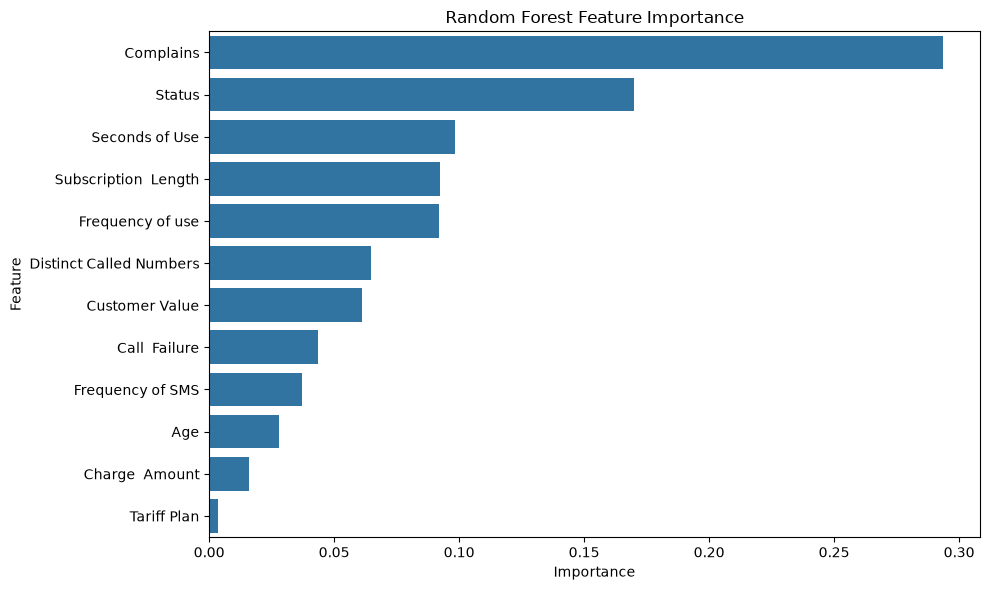

In [114]:
# Feature importance visualization

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_grouped,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [123]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=8
    ),
    "KNN (Tuned)": KNeighborsClassifier(n_neighbors=3)
}

cv_results = []
test_results = []
fitted_pipelines = {}

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    fitted_pipelines[model_name] = pipeline

    cv_results.append({
        "Model": model_name,
        "Mean CV F1": cv_scores.mean(),
        "CV Std": cv_scores.std()
    })

    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

cv_results_df = pd.DataFrame(cv_results)
test_results_df = pd.DataFrame(test_results)

print("CROSS-VALIDATION RESULTS")
print(cv_results_df.round(4))

print("\nTEST SET RESULTS")
print(test_results_df.round(4))

CROSS-VALIDATION RESULTS
                 Model  Mean CV F1  CV Std
0  Logistic Regression      0.5803  0.0463
1        Decision Tree      0.7110  0.0447
2        Random Forest      0.7916  0.0320
3          KNN (Tuned)      0.8305  0.0325

TEST SET RESULTS
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9035     0.8269  0.4831    0.6099
1        Decision Tree    0.9123     0.8000  0.5843    0.6753
2        Random Forest    0.9368     0.9206  0.6517    0.7632
3          KNN (Tuned)    0.9491     0.8488  0.8202    0.8343


In [124]:
final_comparison = test_results_df.merge(
    cv_results_df,
    on="Model"
)

final_comparison = final_comparison[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Mean CV F1",
        "CV Std"
    ]
]

print(final_comparison.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  Mean CV F1  \
0  Logistic Regression    0.9035     0.8269  0.4831    0.6099      0.5803   
1        Decision Tree    0.9123     0.8000  0.5843    0.6753      0.7110   
2        Random Forest    0.9368     0.9206  0.6517    0.7632      0.7916   
3          KNN (Tuned)    0.9491     0.8488  0.8202    0.8343      0.8305   

   CV Std  
0  0.0463  
1  0.0447  
2  0.0320  
3  0.0325  


In [115]:
from sklearn.pipeline import Pipeline

# Create a complete preprocessing + KNN pipeline
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=3))
])

# Perform 5-fold cross-validation
knn_cv_scores = cross_val_score(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("KNN PIPELINE CROSS-VALIDATION")
print("F1 scores for each fold:", knn_cv_scores)
print("Mean CV F1:", knn_cv_scores.mean())
print("Std CV F1:", knn_cv_scores.std())

KNN PIPELINE CROSS-VALIDATION
F1 scores for each fold: [0.83221477 0.87323944 0.7751938  0.82269504 0.84892086]
Mean CV F1: 0.8304527797880695
Std CV F1: 0.03252263925215302


In [116]:
# Train the final KNN pipeline on the full training data

knn_pipeline.fit(X_train, y_train)

# Predict on the untouched test data
final_knn_pred = knn_pipeline.predict(X_test)

# Calculate final metrics
final_accuracy = accuracy_score(y_test, final_knn_pred)
final_precision = precision_score(y_test, final_knn_pred)
final_recall = recall_score(y_test, final_knn_pred)
final_f1 = f1_score(y_test, final_knn_pred)

print("FINAL KNN PIPELINE RESULTS")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)

print("\nClassification Report")
print(classification_report(y_test, final_knn_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, final_knn_pred))

FINAL KNN PIPELINE RESULTS
Accuracy : 0.9491228070175438
Precision: 0.8488372093023255
Recall   : 0.8202247191011236
F1 Score : 0.8342857142857143

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       481
           1       0.85      0.82      0.83        89

    accuracy                           0.95       570
   macro avg       0.91      0.90      0.90       570
weighted avg       0.95      0.95      0.95       570


Confusion Matrix
[[468  13]
 [ 16  73]]


In [117]:
# Final churn profile comparison

important_features = [
    "Customer Value",
    "Seconds of Use",
    "Frequency of use",
    "Frequency of SMS",
    "Distinct Called Numbers",
    "Subscription  Length",
    "Complains",
    "Status",
    "Tariff Plan"
]

churn_profile = df.groupby("Churn")[important_features].mean().T

churn_profile.columns = ["Stayed", "Churned"]

print("CUSTOMER CHURN PROFILE")
print(churn_profile)

CUSTOMER CHURN PROFILE
                              Stayed      Churned
Customer Value            538.590759   132.175695
Seconds of Use           5069.588186  1648.661435
Frequency of use           77.866473    30.697309
Frequency of SMS           84.353577    16.849776
Distinct Called Numbers    25.872296    13.080717
Subscription  Length       32.595674    31.683857
Complains                   0.016639     0.426009
Status                      1.149334     1.728700
Tariff Plan                 1.092762     1.013453


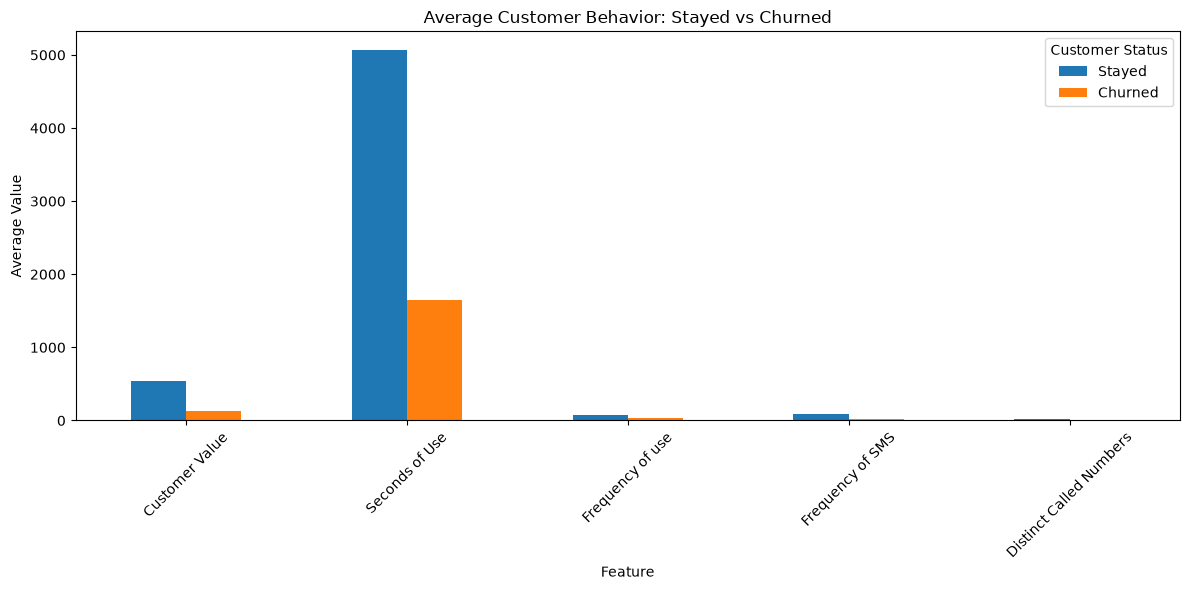

In [118]:
# Compare important numerical features between stayed and churned customers

profile_features = [
    "Customer Value",
    "Seconds of Use",
    "Frequency of use",
    "Frequency of SMS",
    "Distinct Called Numbers"
]

profile_means = df.groupby("Churn")[profile_features].mean().T

profile_means.columns = ["Stayed", "Churned"]

profile_means.plot(kind="bar", figsize=(12, 6))

plt.title("Average Customer Behavior: Stayed vs Churned")
plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Customer Status")
plt.tight_layout()
plt.show()


In [119]:
# Churn rate by important categorical features

categorical_features = [
    "Complains",
    "Tariff Plan",
    "Status"
]

for feature in categorical_features:
    print("\n" + "=" * 50)
    print("Churn Rate by", feature)
    print("=" * 50)

    churn_rate = (
        df.groupby(feature)["Churn"]
        .mean()
        .mul(100)
        .round(2)
    )

    print(churn_rate)


Churn Rate by Complains
Complains
0     9.77
1    82.61
Name: Churn, dtype: float64

Churn Rate by Tariff Plan
Tariff Plan
1    16.79
2     2.62
Name: Churn, dtype: float64

Churn Rate by Status
Status
1     5.59
2    47.51
Name: Churn, dtype: float64


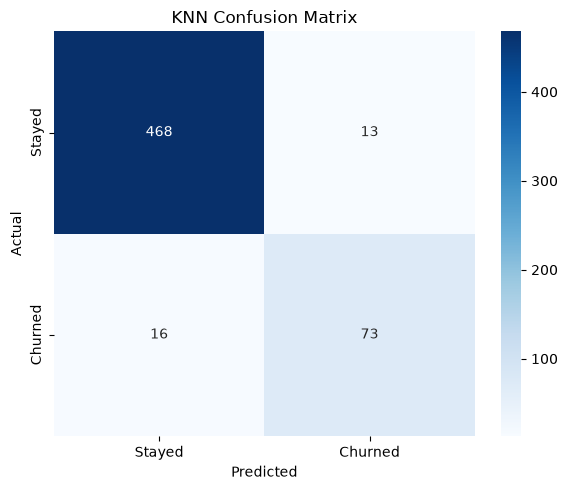

In [120]:
# Final KNN confusion matrix visualization

final_cm = confusion_matrix(y_test, final_knn_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [121]:
# Final model results table

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN (Tuned)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, final_knn_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, tree_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, final_knn_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, tree_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, final_knn_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, tree_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, final_knn_pred)
    ]
})

print("FINAL MODEL COMPARISON")
print(final_results.round(3))

FINAL MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     0.904      0.827   0.483     0.610
1        Decision Tree     0.912      0.800   0.584     0.675
2        Random Forest     0.937      0.921   0.652     0.763
3          KNN (Tuned)     0.949      0.849   0.820     0.834


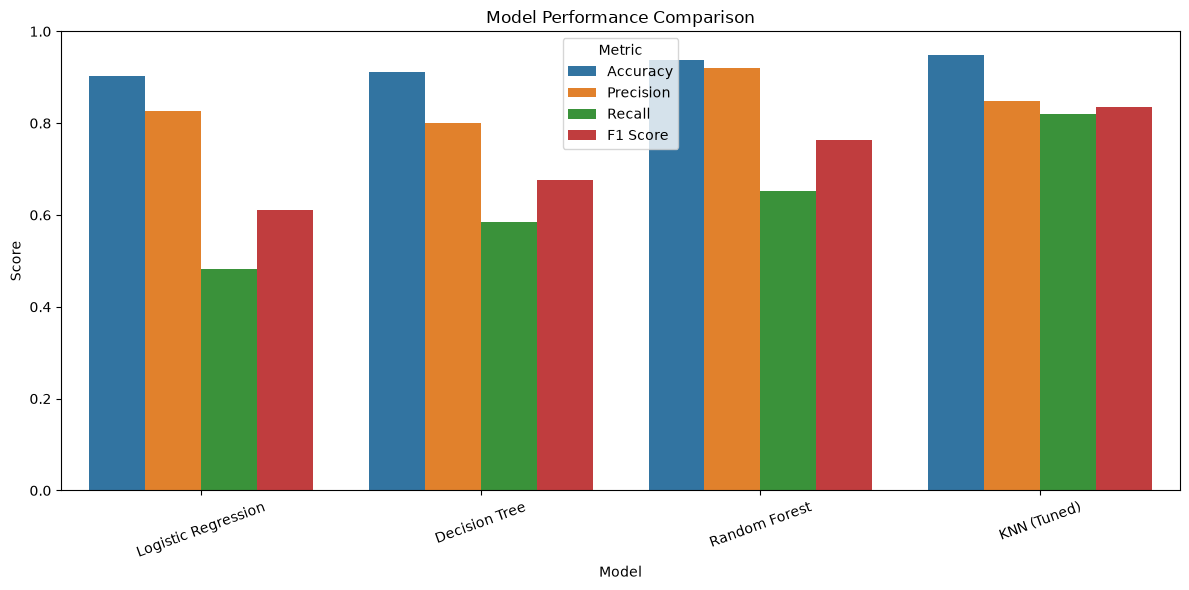

In [122]:
# Visualize model performance

plot_results = final_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_results,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Business Insights


### Key Business Insights

1. **Customer value is associated with churn**

   * Customers who stayed had an average Customer Value of 538.59, compared with 132.18 among churned customers.
   * This indicates that lower-value customers were more represented among the churned group.

2. **Lower customer engagement is associated with churn**

   * Churned customers had substantially lower average usage across Seconds of Use, Frequency of Use, Frequency of SMS, and Distinct Called Numbers.
   * These engagement patterns may help identify customers who require closer attention.

3. **Complaints show a strong association with churn**

   * The observed churn rate was 82.61% among customers who complained, compared with 9.77% among customers who did not.
   * Complaint-related information therefore provides a strong signal for identifying customers with higher observed churn risk.

4. **Categorical customer characteristics show different churn patterns**

   * Tariff Plan and Status showed different churn rates across their categories.
   * Since these variables are coded categories, their underlying business meanings should be confirmed before making specific business recommendations.

5. **The predictive model can support customer retention efforts**

   * The tuned KNN model achieved an F1 score of 83.43% and recall of 82.02% on the test set.
   * It correctly identified 73 of the 89 actual churned customers in the test data.
   * Its mean 5-fold cross-validation F1 score was 83.05%, indicating similar performance across the validation folds.
   * A model like this could be used as a supporting tool to identify customers who may require retention-focused attention.

### Overall Business Takeaway

The analysis indicates that churn is associated with lower customer engagement, lower customer value, and a substantially higher presence of complaints. These patterns can help a telecom business identify potentially at-risk customers and support targeted customer-retention strategies.

However, these findings represent associations observed in the dataset and should not be interpreted as proof that any individual factor directly causes churn.


### Limitations

* The analysis is based on a single telecom customer churn dataset, so the findings may not generalize to other telecom companies or customer populations.
* The dataset contains coded categorical variables such as Tariff Plan and Status. Their exact business meanings are not available in the dataset and should be confirmed before applying the findings operationally.
* The analysis identifies associations between customer characteristics and churn; it does not establish causal relationships.
* The dataset contains duplicate records, which were identified and removed during data cleaning. The final analysis was performed on 2,850 unique records.
* The machine learning models were evaluated using a held-out test set and 5-fold cross-validation. However, further validation on new, unseen customer data would be required before using a model in a production environment.
* The final KNN model achieved an F1 score of 83.43% and recall of 82.02% on the test set, but model performance can vary across different datasets and future customer populations.


### Conclusion

This project analyzed customer churn patterns using customer usage, service, subscription, and value-related data. The analysis combined data cleaning, exploratory data analysis, statistical testing, feature preparation, and machine learning to understand factors associated with customer churn.

The results showed that lower customer engagement, lower customer value, and the presence of complaints were strongly associated with churn in the dataset. Machine learning models were then evaluated using both a held-out test set and 5-fold cross-validation.

Among the evaluated models, the tuned KNN model achieved an F1 score of 83.43% and recall of 82.02% on the test set, with a mean cross-validation F1 score of 83.05%. These results indicate that machine learning can provide a useful supporting approach for identifying customers who may be at higher risk of churn.

Overall, the project demonstrates an end-to-end data analysis workflow, from raw customer data and statistical analysis to predictive modeling and business interpretation. The findings can serve as a foundation for further validation and improvement using additional customer data and real-world business context.


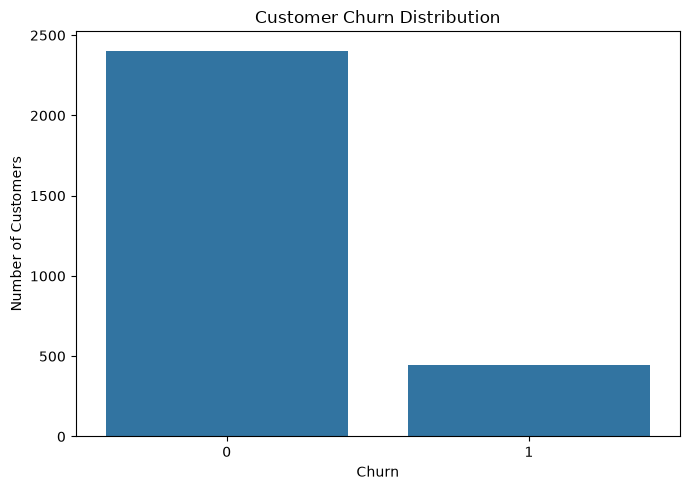

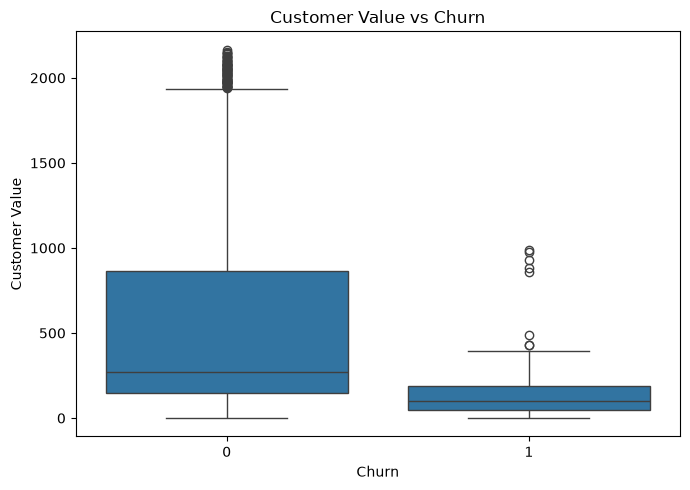

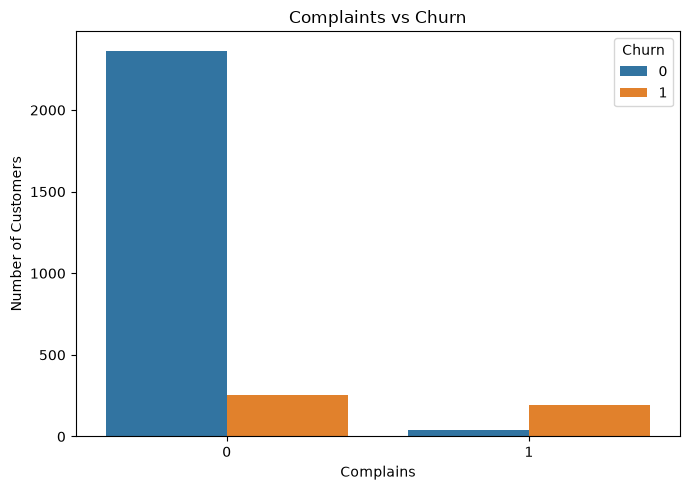

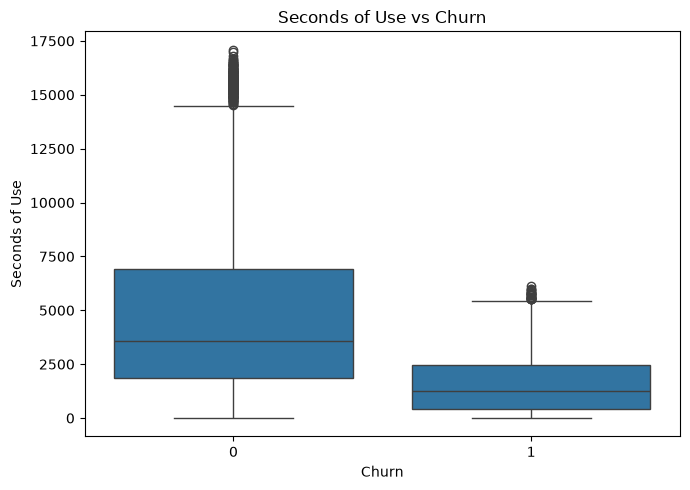

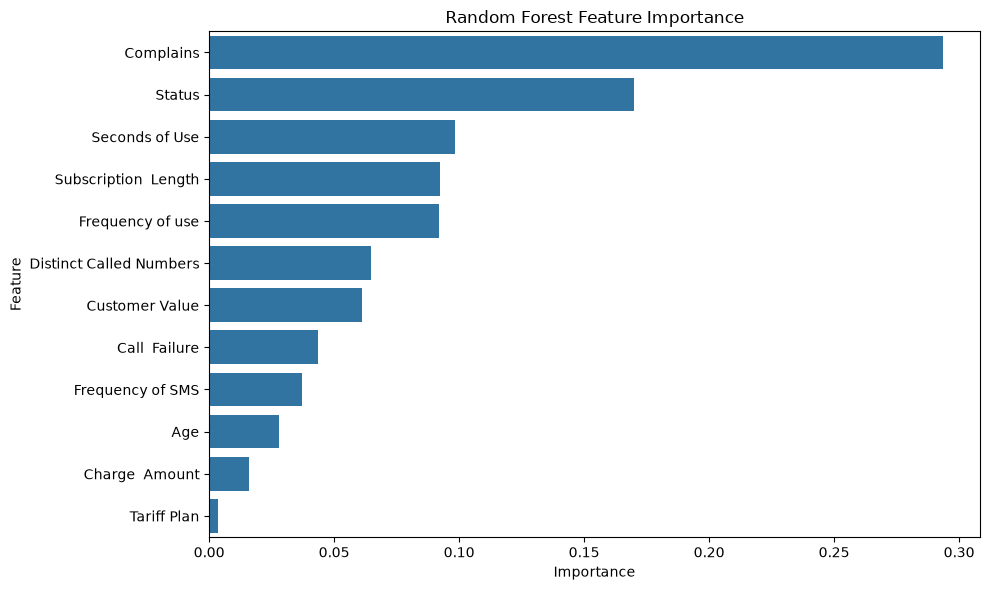

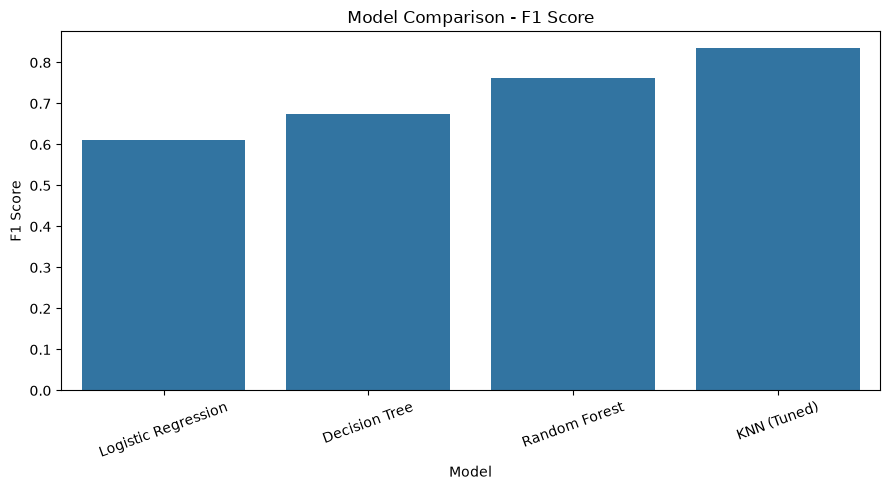

All visualizations saved successfully!
Location: Visualization/


In [129]:
# ============================================================
# SAVE IMPORTANT VISUALIZATIONS FOR GITHUB
# ============================================================

import os

# Create Visualization folder if it doesn't already exist
os.makedirs("../Visualization", exist_ok=True)


# ------------------------------------------------------------
# 1. Churn Distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig(
    "../Visualization/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ------------------------------------------------------------
# 2. Customer Value vs Churn
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Customer Value"
)

plt.title("Customer Value vs Churn")
plt.xlabel("Churn")
plt.ylabel("Customer Value")

plt.tight_layout()
plt.savefig(
    "../Visualization/customer_value_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ------------------------------------------------------------
# 3. Complaints vs Churn
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Complains",
    hue="Churn"
)

plt.title("Complaints vs Churn")
plt.xlabel("Complains")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig(
    "../Visualization/complaints_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ------------------------------------------------------------
# 4. Seconds of Use vs Churn
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Seconds of Use"
)

plt.title("Seconds of Use vs Churn")
plt.xlabel("Churn")
plt.ylabel("Seconds of Use")

plt.tight_layout()
plt.savefig(
    "../Visualization/seconds_of_use_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ------------------------------------------------------------
# 5. Random Forest Feature Importance
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_grouped,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(
    "../Visualization/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ------------------------------------------------------------
# 6. Model Comparison - F1 Score
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=final_comparison,
    x="Model",
    y="F1 Score"
)

plt.title("Model Comparison - F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig(
    "../Visualization/model_comparison_f1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


print("All visualizations saved successfully!")
print("Location: Visualization/")

In [128]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
C:\Users\karth\Customer_Churn_Analysis


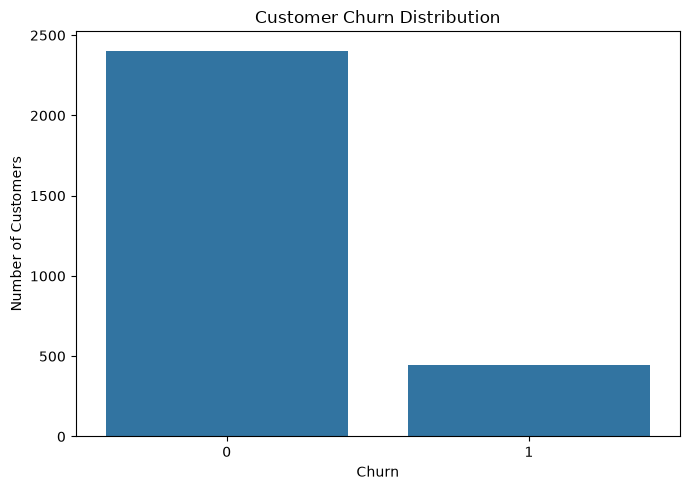

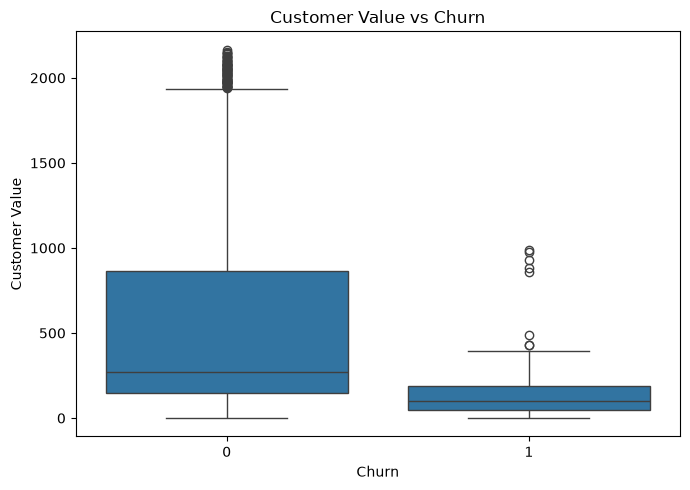

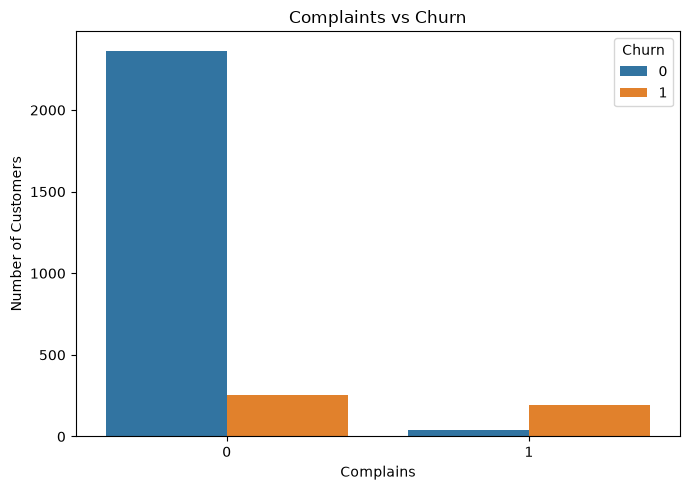

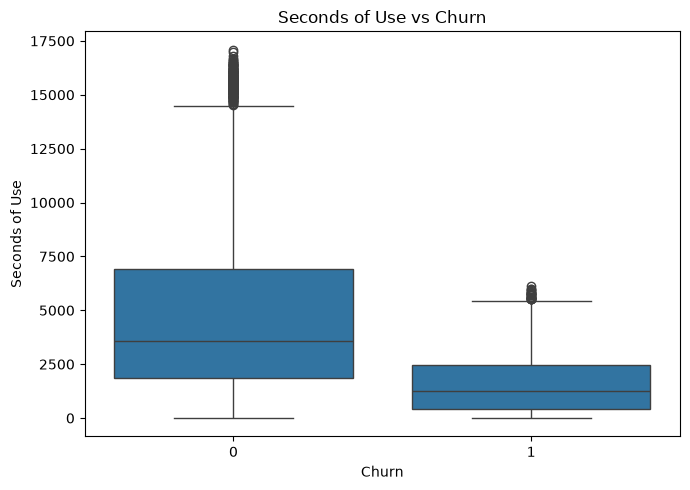

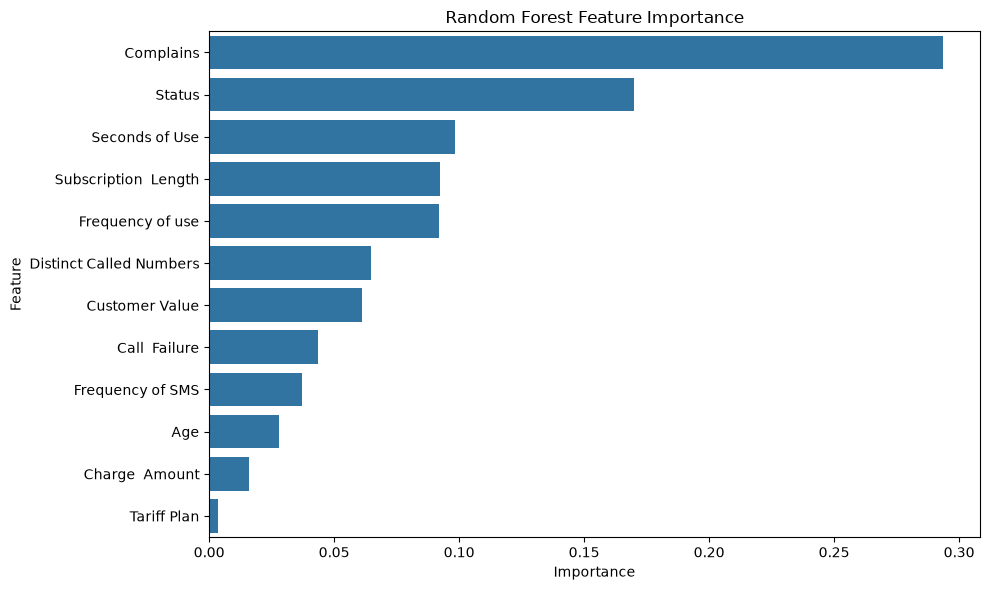

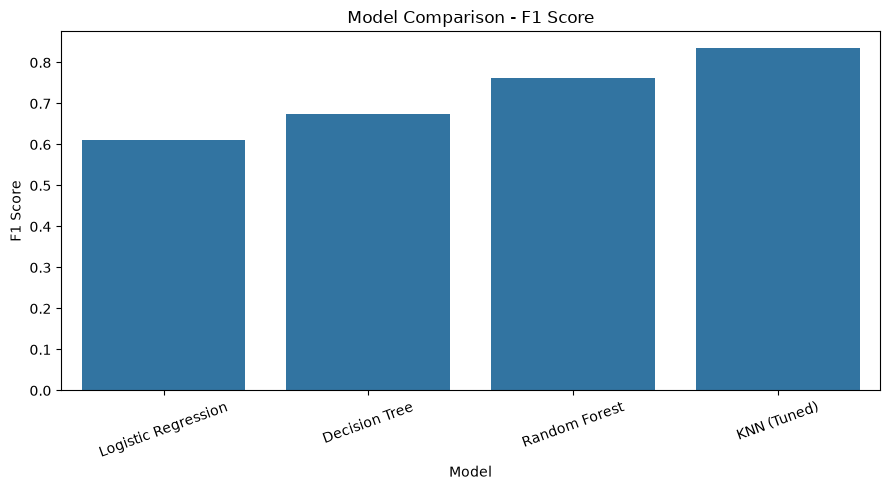

All visualizations saved successfully!
Saved in: C:\Users\karth\Customer_Churn_Analysis\Visualization


In [130]:
# ============================================================
# SAVE IMPORTANT VISUALIZATIONS FOR GITHUB
# ============================================================

import os

# Create Visualization folder if it doesn't exist
os.makedirs("Visualization", exist_ok=True)


# ------------------------------------------------------------
# 1. Churn Distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig(
    "Visualization/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ------------------------------------------------------------
# 2. Customer Value vs Churn
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Customer Value"
)

plt.title("Customer Value vs Churn")
plt.xlabel("Churn")
plt.ylabel("Customer Value")

plt.tight_layout()
plt.savefig(
    "Visualization/customer_value_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ------------------------------------------------------------
# 3. Complaints vs Churn
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Complains",
    hue="Churn"
)

plt.title("Complaints vs Churn")
plt.xlabel("Complains")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig(
    "Visualization/complaints_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ------------------------------------------------------------
# 4. Seconds of Use vs Churn
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Seconds of Use"
)

plt.title("Seconds of Use vs Churn")
plt.xlabel("Churn")
plt.ylabel("Seconds of Use")

plt.tight_layout()
plt.savefig(
    "Visualization/seconds_of_use_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ------------------------------------------------------------
# 5. Random Forest Feature Importance
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_grouped,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(
    "Visualization/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ------------------------------------------------------------
# 6. Model Comparison - F1 Score
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=final_comparison,
    x="Model",
    y="F1 Score"
)

plt.title("Model Comparison - F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig(
    "Visualization/model_comparison_f1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


print("All visualizations saved successfully!")
print("Saved in:", os.path.abspath("Visualization"))